<a href="https://colab.research.google.com/github/narwayvivek/genai-bronze-certification/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(90deg, #2c3e50 0%, #3498db 100%);
            padding: 25px; border-radius: 20px; text-align: center;
            color: white; font-family: 'Arial Black', sans-serif;
            box-shadow: 0 10px 40px rgba(0,0,0,0.4); margin: 20px 0;
            border: 3px solid #ecf0f1;">

**💼 VIVEK NARWAY**  
**🏢 SAP ID: 52217413**  


</div>

**Problem Statement**

A financial institution wants to **predict whether a customer will default on a loan** before approving it. Early identification of risky customers helps reduce **financial loss**.

You are working as a **Machine Learning Analyst** and must build a **classification model using the K-Nearest Neighbors (KNN) algorithm** to predict loan default.

**This case introduces:**
- **Mixed feature types**
- **Financial risk interpretation**
- **Class imbalance awareness**

**Dataset:**
**Dataset:**

| Age | AnnualIncome(lakhs) | CreditScore(300-900) | LoanAmount(lakhs) | LoanTerm(years) | EmploymentType  | loan(yes/no) |
|-----|-------------------|---------------------|------------------|----------------|----------------|-------------|
| 28  | 6.5                | 720                 | 5                | 5              | Salaried       | 0           |
| 45  | 12                 | 680                 | 10               | 10             | Self-Employed  | 1           |
| 35  | 8                  | 750                 | 6                | 7              | Salaried       | 0           |
| 50  | 15                 | 640                 | 12               | 15             | Self-Employed  | 1           |
| 30  | 7                  | 710                 | 5                | 5              | Salaried       | 0           |
| 42  | 10                 | 660                 | 9                | 10             | Salaried       | 1           |
| 26  | 5.5                | 730                 | 4                | 4              | Salaried       | 0           |
| 48  | 14                 | 650                 | 11               | 12             | Self-Employed  | 1           |
| 38  | 9                  | 700                 | 7                | 8              | Salaried       | 0           |
| 55  | 16                 | 620                 | 13               | 15             | Self-Employed  | 1           |

**Interpretation Questions:**
1. **Identify high-risk customers.**
2. **What patterns lead to loan default?**
3. **How do credit score and income influence predictions?**
4. **Suggest banking policies based on model output.**
5. **Compare KNN with Decision Trees for this problem.**
6. **What happens if LoanAmount dominates distance calculation?**
7. **Should KNN be used in real-time loan approval systems?**


🏦 LOAN DEFAULT PREDICTION USING KNN CLASSIFIER
Age + Income + CreditScore + Loan + Term + Employment → Default
✅ Loaded from loan_default.csv

Employment Encoding: {'Salaried': np.int64(0), 'Self-Employed': np.int64(1)}

MODEL PERFORMANCE
Cross-Validation Accuracy: 0.778
Training Accuracy: 0.857
Test Accuracy: 1.000

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00         2
     Default       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



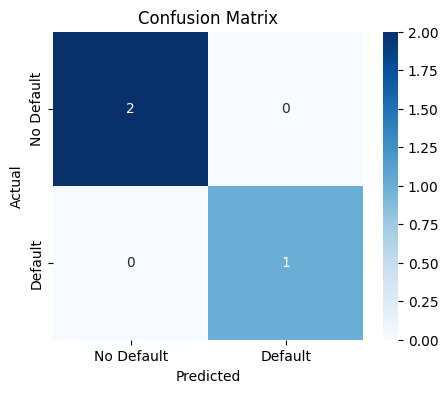

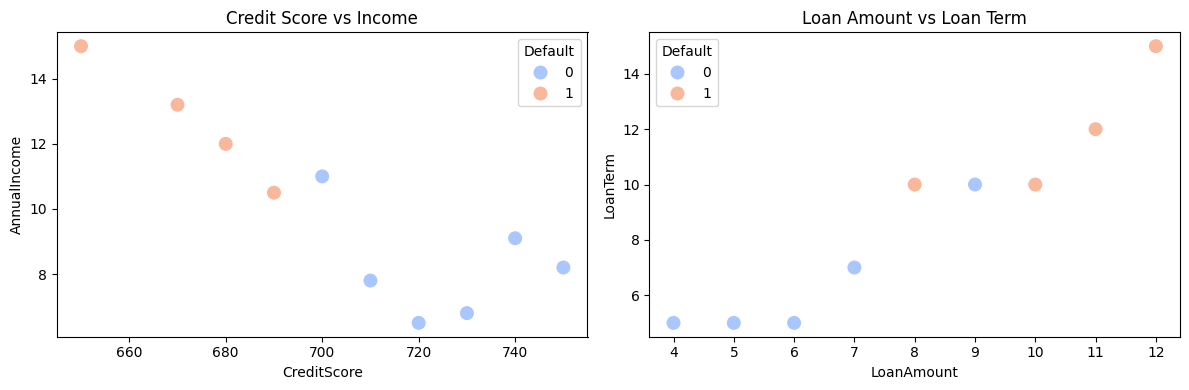


📌 INTERPRETATION & BUSINESS INSIGHTS
1. HIGH-RISK CUSTOMERS:
   • Low credit score (<680)
   • High loan amount with long tenure
   • Self-employed applicants show higher default risk

2. DEFAULT PATTERNS:
   • Credit score is the strongest predictor
   • Higher loan burden increases default probability

3. CREDIT SCORE & INCOME EFFECT:
   • Higher credit score significantly reduces default risk
   • Higher income supports repayment but cannot offset poor credit

4. BANKING POLICY SUGGESTIONS:
   • Stricter checks for low credit score applicants
   • Limit loan tenure for high-risk profiles
   • Prefer salaried applicants for large loans

5. KNN vs DECISION TREE:
   • KNN: Distance-based, sensitive to scaling, less interpretable
   • Decision Tree: Faster, explainable, preferred in banking

6. IF LOAN AMOUNT DOMINATES DISTANCE:
   • Model becomes biased
   • Feature scaling prevents this issue

7. REAL-TIME LOAN APPROVAL:
   • KNN is NOT ideal due to prediction latency
   • Logistic R

In [4]:
# ============================================================
# LOAN DEFAULT PREDICTION - KNN CLASSIFICATION MODEL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=" * 70)
print("🏦 LOAN DEFAULT PREDICTION USING KNN CLASSIFIER")
print("Age + Income + CreditScore + Loan + Term + Employment → Default")
print("=" * 70)

# ------------------------------------------------------------
# 1. DATASET
# ------------------------------------------------------------
try:
    # Professional: Load from CSV
    df = pd.read_csv('loan_default.csv')
    print("✅ Loaded from loan_default.csv")
except FileNotFoundError:
    # Fallback:
    print("⚠️ CSV not found, using embedded data...")
    data = {
        'Age': [28,45,35,50,30,42,26,48,38,55],
        'AnnualIncome': [6.5,12,8,15,7,10,5.5,14,9,16],
        'CreditScore': [720,680,750,640,710,660,730,650,700,620],
        'LoanAmount': [5,10,6,12,5,9,4,11,7,13],
        'LoanTerm': [5,10,7,15,5,10,4,12,8,15],
        'EmploymentType': ['Salaried','Self-Employed','Salaried','Self-Employed',
                          'Salaried','Salaried','Salaried','Self-Employed',
                          'Salaried','Self-Employed'],
        'Default': [0,1,0,1,0,1,0,1,0,1]
    }
    df = pd.DataFrame(data)


# ------------------------------------------------------------
# 2. ENCODING CATEGORICAL FEATURE

# ------------------------------------------------------------
le = LabelEncoder()
df['EmploymentEncoded'] = le.fit_transform(df['EmploymentType'])

X = df[['Age', 'AnnualIncome', 'CreditScore',
        'LoanAmount', 'LoanTerm', 'EmploymentEncoded']]
y = df['Default']

print("\nEmployment Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# ------------------------------------------------------------
# 3. FEATURE SCALING
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 4. TRAIN–TEST SPLIT (Stratified)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 5. KNN MODEL
# ------------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(knn, X_scaled, y, cv=3)

print("\nMODEL PERFORMANCE")
print(f"Cross-Validation Accuracy: {cv_scores.mean():.3f}")
print(f"Training Accuracy: {knn.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {knn.score(X_test, y_test):.3f}")

# ------------------------------------------------------------
# 6. PREDICTIONS & RISK IDENTIFICATION
# ------------------------------------------------------------
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Default','Default']))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ------------------------------------------------------------
# 7. VISUAL EXPLORATION
# ------------------------------------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.scatterplot(data=df, x='CreditScore', y='AnnualIncome',
                hue='Default', palette='coolwarm', s=120)
plt.title("Credit Score vs Income")

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='LoanAmount', y='LoanTerm',
                hue='Default', palette='coolwarm', s=120)
plt.title("Loan Amount vs Loan Term")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. INTERPRETATION & BUSINESS INSIGHTS
# ------------------------------------------------------------
print("\n" + "="*80)
print("📌 INTERPRETATION & BUSINESS INSIGHTS")
print("="*80)

print("1. HIGH-RISK CUSTOMERS:")
print("   • Low credit score (<680)")
print("   • High loan amount with long tenure")
print("   • Self-employed applicants show higher default risk\n")

print("2. DEFAULT PATTERNS:")
print("   • Credit score is the strongest predictor")
print("   • Higher loan burden increases default probability\n")

print("3. CREDIT SCORE & INCOME EFFECT:")
print("   • Higher credit score significantly reduces default risk")
print("   • Higher income supports repayment but cannot offset poor credit\n")

print("4. BANKING POLICY SUGGESTIONS:")
print("   • Stricter checks for low credit score applicants")
print("   • Limit loan tenure for high-risk profiles")
print("   • Prefer salaried applicants for large loans\n")

print("5. KNN vs DECISION TREE:")
print("   • KNN: Distance-based, sensitive to scaling, less interpretable")
print("   • Decision Tree: Faster, explainable, preferred in banking\n")

print("6. IF LOAN AMOUNT DOMINATES DISTANCE:")
print("   • Model becomes biased")
print("   • Feature scaling prevents this issue\n")

print("7. REAL-TIME LOAN APPROVAL:")
print("   • KNN is NOT ideal due to prediction latency")
print("   • Logistic Regression or Decision Trees are better choices\n")

print("FINAL CONCLUSION:")
print("KNN effectively highlights risk patterns but is best used for analysis,")
print("not direct real-time loan approval systems.")
